## Check GPU presence

In [1]:
import sys
print(sys.executable)
print(sys.version)

#import sys
#!{sys.executable} -m pip uninstall torch torchvision torchaudio -y
#!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

import torch
import torchvision

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

C:\Users\aaron\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
PyTorch: 2.5.1+cu121
Torchvision: 0.20.1+cu121
CUDA available: True


In [2]:
from torch.utils.data import Dataset

# Custom Dataset class
class ChipDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # Add dtype=torch.long
        return image, label

!pip install --upgrade pip --quiet

## Collect / analyze image database

Collect all images in the database, count the number of samples in each brand, and present in a plot. For this model, each model must have a minimum of 20 images to be used.

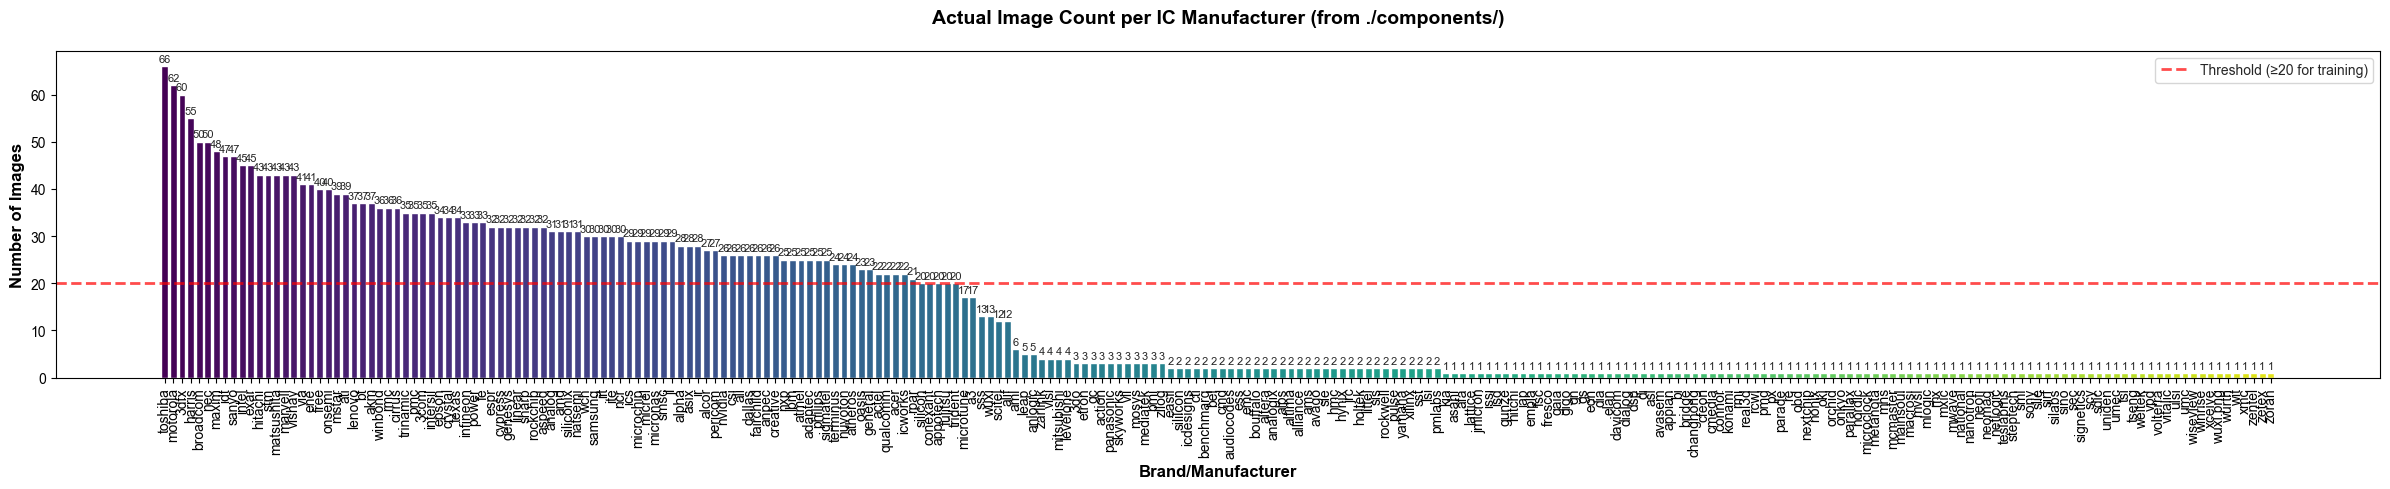

In [3]:
# Section 1: Data Augmentation & Dataset Setup
import os
from PIL import Image
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Define your data directory
DATA_DIR = './components/'

# Scan the directory and build the dataset directly from files
brand_counts = Counter()
all_files = []

for filename in os.listdir(DATA_DIR):
    if filename.endswith('.png'):
        brand = filename.split('_')[0]
        brand_counts[brand] += 1
        all_files.append(filename)

# Create dataframe from actual files
df = pd.DataFrame([
    {'Brand': brand, 'Moniker': brand, 'Count': count}
    for brand, count in brand_counts.items()
]).sort_values('Count', ascending=False)

# Create visualization
fig, ax = plt.subplots(figsize=(24, 5))
sns.set_style("whitegrid")

# Create bar plot using matplotlib directly for better control
x_positions = range(len(df))
bars = ax.bar(x_positions, df['Count'], color=plt.cm.viridis(range(len(df))))

# Customize the plot
ax.set_xticks(x_positions)
ax.set_xticklabels(df['Brand'], rotation=90, ha='center')  # Changed to ha='center'
ax.set_xlabel('Brand/Manufacturer', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax.set_title('Actual Image Count per IC Manufacturer (from ./components/)', fontsize=14, fontweight='bold', pad=20)

# Add value labels on top of bars
for i, (pos, count) in enumerate(zip(x_positions, df['Count'])):
    ax.text(pos, count + 0.5, str(count), ha='center', va='bottom', fontsize=8)

# Add threshold line
ax.axhline(y=20, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Threshold (≥20 for training)')
ax.legend()

plt.tight_layout()
plt.show()

# Filter to brands with >= 20 images
min_df = df[df['Count'] >= 20].copy()

# Get list of valid brands (these will be your classes)
valid_brands = min_df['Moniker'].tolist()
brand_to_idx = {brand: idx for idx, brand in enumerate(sorted(valid_brands))}
idx_to_brand = {idx: brand for brand, idx in brand_to_idx.items()}

# Collect all valid images (only from brands with >= 20 images)
image_paths = []
labels = []

for filename in all_files:
    brand = filename.split('_')[0]
    
    if brand in brand_to_idx:
        image_paths.append(os.path.join(DATA_DIR, filename))
        labels.append(brand_to_idx[brand])

### Set up annotation

In [4]:
# ============================================================
# STEP 1: Check your current file structure
# ============================================================

import os

# Check what directories you currently have
print("Current working directory:", os.getcwd())
print("\nContents:")
for item in sorted(os.listdir('.')):
    if os.path.isdir(item):
        count = len(os.listdir(item))

# Check your components folder specifically
if os.path.exists('./components'):
    files = os.listdir('./components')
    img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

Current working directory: C:\Users\aaron\Dropbox\AI Projects\logo-reader

Contents:


In [5]:
# ============================================================
# STEP 2: Set up annotation workspace from your existing data
# ============================================================

import os
import shutil

def setup_workspace():
    """
    Creates the annotation workspace and copies your
    existing images from ./components/ into it
    """
    
    # Define paths
    source_dir = './components/'
    workspace = './annotation_workspace/'
    
    # Create directory structure
    dirs_to_create = [
        f'{workspace}/images/train',
        f'{workspace}/images/val',
        f'{workspace}/labels/train',
        f'{workspace}/labels/val',
    ]
    
    for d in dirs_to_create:
        os.makedirs(d, exist_ok=True)
        print(f"  ✓ Created: {d}")
    
    # Get all images from components
    all_images = [f for f in os.listdir(source_dir) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    # Split: 85% train, 15% val (maintaining your existing ratios)
    import random
    random.seed(42)
    random.shuffle(all_images)
    
    split_idx = int(len(all_images) * 0.85)
    train_images = all_images[:split_idx]
    val_images = all_images[split_idx:]
    
    # Copy to workspace
    print(f"\nCopying {len(train_images)} training images...")
    for f in train_images:
        shutil.copy(
            os.path.join(source_dir, f),
            os.path.join(f'{workspace}/images/train', f)
        )
    
    print(f"Copying {len(val_images)} validation images...")
    for f in val_images:
        shutil.copy(
            os.path.join(source_dir, f),
            os.path.join(f'{workspace}/images/val', f)
        )
    
    # Create classes.txt - IMPORTANT: this defines your class IDs
    # Class 0 = background (implicit in Faster R-CNN)
    # We only need ONE class for the detector: "logo"
    # The classifier (Stage 2) handles WHICH manufacturer
    classes = ['logo']  # Just one class - we only need to FIND the logo
    
    with open(f'{workspace}/classes.txt', 'w') as f:
        for cls in classes:
            f.write(f"{cls}\n")
    
    print(f"\n✓ Created classes.txt: {classes}")
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"WORKSPACE SETUP COMPLETE")
    print(f"{'='*60}")
    print(f"  Training images:   {len(train_images)}")
    print(f"  Validation images: {len(val_images)}")
    print(f"  Classes:           {classes}")
    print(f"\n  Workspace location: {os.path.abspath(workspace)}")
    print(f"{'='*60}")
    
    print(f"""
NEXT STEPS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Open a terminal/command prompt
2. Run: pip install labelImg
3. Run: labelImg
4. In LabelImg:
   a. Click 'Open Dir'
      → Navigate to: {os.path.abspath(f'{workspace}/images/train')}
   b. Click 'Change Save Dir'  
      → Navigate to: {os.path.abspath(f'{workspace}/labels/train')}
   c. Check that format is set to YOLO (button on left side)
   d. Click the classes.txt 'Load' button and load:
      → {os.path.abspath(f'{workspace}/classes.txt')}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# Run setup
setup_workspace()

  ✓ Created: ./annotation_workspace//images/train
  ✓ Created: ./annotation_workspace//images/val
  ✓ Created: ./annotation_workspace//labels/train
  ✓ Created: ./annotation_workspace//labels/val

Copying 2863 training images...
Copying 506 validation images...

✓ Created classes.txt: ['logo']

WORKSPACE SETUP COMPLETE
  Training images:   2863
  Validation images: 506
  Classes:           ['logo']

  Workspace location: C:\Users\aaron\Dropbox\AI Projects\logo-reader\annotation_workspace

NEXT STEPS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Open a terminal/command prompt
2. Run: pip install labelImg
3. Run: labelImg
4. In LabelImg:
   a. Click 'Open Dir'
      → Navigate to: C:\Users\aaron\Dropbox\AI Projects\logo-reader\annotation_workspace\images\train
   b. Click 'Change Save Dir'  
      → Navigate to: C:\Users\aaron\Dropbox\AI Projects\logo-reader\annotation_workspace\labels\train
   c. Check that format is set to YOLO (button on left side)
   d. Click the classes.

## Reduce dataset to minimum viable brands

To be used in the model, each brand must contain a minimum of 20 samples. Brands with less than 20 samples are discarded from the dataset.

In [6]:
# Section 3: Download/Build the Model
import torch.nn as nn
from torchvision import models

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

# Load pretrained ResNet-18
print(f"\n{'='*60}")
print("Loading ResNet-18 with ImageNet pretrained weights...")

model = models.resnet18(pretrained=True)

# Freeze early layers (optional - keeps ImageNet features)
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
num_classes = len(brand_to_idx)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU/CPU
model = model.to(device)

print(f"Model architecture modified:")
print(f"  Original output: 1000 classes (ImageNet)")
print(f"  New output: {num_classes} classes (IC brands)")
print(f"  Frozen layers: Early conv layers (transfer learning)")
print(f"  Trainable layers: Final FC layer")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel parameters:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Frozen parameters: {total_params - trainable_params:,}")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)

print(f"\nTraining configuration:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"\nModel ready for training!")

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Memory: 6.00 GB

Loading ResNet-18 with ImageNet pretrained weights...


C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model architecture modified:
  Original output: 1000 classes (ImageNet)
  New output: 93 classes (IC brands)
  Frozen layers: Early conv layers (transfer learning)
  Trainable layers: Final FC layer

Model parameters:
  Total parameters: 11,224,221
  Trainable parameters: 47,709
  Frozen parameters: 11,176,512

Training configuration:
  Loss function: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=3)

Model ready for training!


C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Split dataset into train / test / validation (80 / (80/20))

In [7]:
# Section 2: Train/Test/Validation Split with Balanced Sampling
from sklearn.model_selection import train_test_split
import numpy as np
from torchvision import transforms
from torch.utils.data import WeightedRandomSampler

# Convert to numpy arrays for easier manipulation
image_paths = np.array(image_paths)  # FIXED: No dtype for strings
labels = np.array(labels, dtype=np.int64)

print(f"Total dataset: {len(image_paths)} images")
print(f"Number of classes: {len(brand_to_idx)}")

# First split: 80% train+val, 20% test
# Stratify to ensure each brand is represented proportionally in each split
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    image_paths, 
    labels, 
    test_size=0.2,  # 20% for test
    stratify=labels,  # Maintain class distribution
    random_state=42
)

# Second split: Split train+val into 80% train, 20% val
# From the remaining 80%, take 20% for validation (which is 16% of total)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths,
    train_val_labels,
    test_size=0.2,  # 20% of train_val = 16% of total
    stratify=train_val_labels,
    random_state=42
)

# Final split: ~64% train, ~16% val, ~20% test
print(f"\n{'='*60}")
print(f"Split Summary:")
print(f"  Training:   {len(train_paths)} images ({len(train_paths)/len(image_paths)*100:.1f}%)")
print(f"  Validation: {len(val_paths)} images ({len(val_paths)/len(image_paths)*100:.1f}%)")
print(f"  Test:       {len(test_paths)} images ({len(test_paths)/len(image_paths)*100:.1f}%)")

# Calculate class weights for balanced sampling
print(f"\n{'='*60}")
print("Setting up balanced sampling for training...")
print(f"{'='*60}")

# Count samples per class in training set
class_counts = {}
for label in train_labels:
    class_counts[label] = class_counts.get(label, 0) + 1

# Calculate sample weights (inverse frequency)
# Classes with fewer samples get higher weight
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]

# Create weighted sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Allow sampling with replacement for balance
)

# Training augmentations
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation/Test augmentations
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with appropriate transforms
train_dataset = ChipDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = ChipDataset(val_paths, val_labels, transform=val_test_transforms)
test_dataset = ChipDataset(test_paths, test_labels, transform=val_test_transforms)

print(f"\n{'='*60}")
print(f"Datasets created:")
print(f"  Training dataset:   {len(train_dataset)} samples (with augmentation)")
print(f"  Validation dataset: {len(val_dataset)} samples (no augmentation)")
print(f"  Test dataset:       {len(test_dataset)} samples (no augmentation)")

# Create data loaders
BATCH_SIZE = 32

# Training loader uses weighted sampler for balanced class representation
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,  # Use weighted sampler instead of shuffle
    num_workers=0,  # Windows fix
    pin_memory=True if torch.cuda.is_available() else False
)

# Validation and test loaders don't need balancing
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"\nDataLoaders created:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Training batches:   {len(train_loader)} (balanced sampling)")
print(f"  Validation batches: {len(val_loader)}")
print(f"  Test batches:       {len(test_loader)}")
print(f"\n{'='*60}")
print("✓ Balanced sampling ensures equal representation during training")
print("✓ Rare classes are sampled more frequently")
print("✓ Common classes are sampled less frequently")
print(f"{'='*60}")

Total dataset: 3059 images
Number of classes: 93

Split Summary:
  Training:   1957 images (64.0%)
  Validation: 490 images (16.0%)
  Test:       612 images (20.0%)

Setting up balanced sampling for training...

Datasets created:
  Training dataset:   1957 samples (with augmentation)
  Validation dataset: 490 samples (no augmentation)
  Test dataset:       612 samples (no augmentation)

DataLoaders created:
  Batch size: 32
  Training batches:   62 (balanced sampling)
  Validation batches: 16
  Test batches:       20

✓ Balanced sampling ensures equal representation during training
✓ Rare classes are sampled more frequently
✓ Common classes are sampled less frequently


## Train logo identification model

In [8]:
# ============================================================
# CELL 1: TRAIN LOGO DETECTOR ONLY - WITH FORCED OUTPUT
# ============================================================

import torch
import torch.nn as nn
from torchvision import models
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision import transforms
from PIL import Image
import os
import sys

# ============================================================
# DETECTOR MODEL DEFINITION
# ============================================================

def get_logo_detector(num_classes=2):
    """Create Faster R-CNN model for logo detection"""
    model = fasterrcnn_resnet50_fpn(weights='DEFAULT')
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# ============================================================
# DATASET CLASS FOR DETECTION
# ============================================================

class LogoDetectionDataset(torch.utils.data.Dataset):
    """Dataset for logo detection training (YOLO format annotations)"""
    
    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        
        self.image_files = []
        for f in os.listdir(image_dir):
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                label_file = os.path.splitext(f)[0] + '.txt'
                if os.path.exists(os.path.join(label_dir, label_file)):
                    self.image_files.append(f)
        
        print(f"✓ Found {len(self.image_files)} annotated images", flush=True)
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_file)
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_file)
        
        # Load image
        img = Image.open(img_path).convert('RGB')
        img_width, img_height = img.size
        img_tensor = transforms.ToTensor()(img)
        
        # Load YOLO annotation
        boxes = []
        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                
                class_id, x_center, y_center, w, h = map(float, parts)
                
                # YOLO normalized → pixel coordinates
                x_min = (x_center - w / 2) * img_width
                y_min = (y_center - h / 2) * img_height
                x_max = (x_center + w / 2) * img_width
                y_max = (y_center + h / 2) * img_height
                
                boxes.append([x_min, y_min, x_max, y_max])
        
        if len(boxes) == 0:
            boxes = [[0, 0, 10, 10]]
            labels = torch.zeros(1, dtype=torch.int64)
        else:
            labels = torch.ones(len(boxes), dtype=torch.int64)
        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros(len(boxes), dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'area': area,
            'iscrowd': iscrowd,
            'image_id': torch.tensor([idx])
        }
        
        return img_tensor, target


def collate_fn(batch):
    """Custom collate since images are different sizes"""
    return tuple(zip(*batch))

# ============================================================
# TRAIN THE DETECTOR - WITH FORCED OUTPUT FLUSHING
# ============================================================

def train_logo_detector(image_dir, label_dir, num_epochs=15, batch_size=2, lr=0.005):
    """Train the logo detection model"""
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}", flush=True)
    
    # Load dataset
    dataset = LogoDetectionDataset(image_dir, label_dir)
    dataloader = torch.utils.data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=collate_fn,
        num_workers=0
    )
    
    # Load model
    print(f"\nLoading Faster R-CNN model...", flush=True)
    model = get_logo_detector(num_classes=2)
    model = model.to(device)
    print(f"✓ Model loaded to {device}", flush=True)
    
    # Optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=0.0005)
    
    # Training loop
    print(f"\nTraining logo detector for {num_epochs} epochs...", flush=True)
    print(f"Batches per epoch: {len(dataloader)}", flush=True)
    print("="*60, flush=True)
    
    import time
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        epoch_start = time.time()
        
        for batch_idx, (images, targets) in enumerate(dataloader):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            epoch_loss += losses.item()
            num_batches += 1
            
            # Progress update every 20% of batches
            if (batch_idx + 1) % max(1, len(dataloader) // 5) == 0:
                progress = (batch_idx + 1) / len(dataloader) * 100
                avg_loss_so_far = epoch_loss / num_batches
                print(f"  Epoch {epoch+1}/{num_epochs} - {progress:>5.0f}% - "
                      f"Batch {batch_idx+1:>4}/{len(dataloader)} - "
                      f"Loss: {avg_loss_so_far:.4f}", flush=True)
        
        epoch_time = time.time() - epoch_start
        avg_loss = epoch_loss / num_batches
        
        print(f"Epoch {epoch+1:2d}/{num_epochs} COMPLETE: "
              f"Loss={avg_loss:.4f}, "
              f"Time={epoch_time:.1f}s", flush=True)
        print("-"*60, flush=True)
    
    # Save trained detector
    torch.save(model.state_dict(), 'logo_detector.pth')
    print("\n✓ Logo detector saved: logo_detector.pth", flush=True)
    print("="*60, flush=True)
    
    return model

# ============================================================
# RUN TRAINING
# ============================================================

detector = train_logo_detector(
    image_dir='annotation_workspace/images/train',
    label_dir='annotation_workspace/labels/train',
    num_epochs=15,
    batch_size=2
)

print("\n✓ Detector training complete!", flush=True)
print("  Model saved: logo_detector.pth", flush=True)

Using device: cuda
✓ Found 3382 annotated images

Loading Faster R-CNN model...
✓ Model loaded to cuda

Training logo detector for 15 epochs...
Batches per epoch: 1691
  Epoch 1/15 -    20% - Batch  338/1691 - Loss: 0.1510
  Epoch 1/15 -    40% - Batch  676/1691 - Loss: 0.1325
  Epoch 1/15 -    60% - Batch 1014/1691 - Loss: 0.1238
  Epoch 1/15 -    80% - Batch 1352/1691 - Loss: 0.1168
  Epoch 1/15 -   100% - Batch 1690/1691 - Loss: 0.1122
Epoch  1/15 COMPLETE: Loss=0.1122, Time=913.0s
------------------------------------------------------------
  Epoch 2/15 -    20% - Batch  338/1691 - Loss: 0.0827
  Epoch 2/15 -    40% - Batch  676/1691 - Loss: 0.0831
  Epoch 2/15 -    60% - Batch 1014/1691 - Loss: 0.0826
  Epoch 2/15 -    80% - Batch 1352/1691 - Loss: 0.0823
  Epoch 2/15 -   100% - Batch 1690/1691 - Loss: 0.0825
Epoch  2/15 COMPLETE: Loss=0.0825, Time=823.3s
------------------------------------------------------------
  Epoch 3/15 -    20% - Batch  338/1691 - Loss: 0.0688
  Epoch 3/1

# Train logo classifier on logo crops

In [9]:
##### ============================================================
# CELL 2: TRAIN LOGO CLASSIFIER (STAGE 2)
# ============================================================

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

# Enable cuDNN optimization
torch.backends.cudnn.benchmark = True

# ============================================================
# STEP 1: EXTRACT LOGO CROPS USING DETECTOR
# ============================================================

def load_detector_for_cropping(model_path='logo_detector.pth'):
    """Load trained detector to extract logo crops"""
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

    model = fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)
    
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    print(f"✓ Loaded detector: {model_path}")
    return model


def extract_logo_crops(detector, source_dir, output_dir, confidence_threshold=0.7):
    """
    Use detector to crop logos from all images
    """
    
    print(f"\n{'='*60}")
    print("EXTRACTING LOGO CROPS")
    print(f"{'='*60}\n")
    
    os.makedirs(output_dir, exist_ok=True)
    
    image_files = [f for f in os.listdir(source_dir)
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    print(f"Processing {len(image_files)} images...")
    
    extracted = 0
    skipped = 0
    
    for idx, img_file in enumerate(image_files):
        manufacturer = img_file.split('_')[0]
        
        mfr_dir = os.path.join(output_dir, manufacturer)
        os.makedirs(mfr_dir, exist_ok=True)
        
        img_path = os.path.join(source_dir, img_file)
        img = Image.open(img_path).convert('RGB')
        
        # Run detection
        img_tensor = transforms.ToTensor()(img).to(device)
        with torch.no_grad():
            pred = detector([img_tensor])
        
        boxes = pred[0]['boxes'].cpu().numpy()
        scores = pred[0]['scores'].cpu().numpy()
        
        if len(scores) == 0 or scores.max() < confidence_threshold:
            skipped += 1
            continue
        
        # Get best detection
        best_idx = scores.argmax()
        x1, y1, x2, y2 = boxes[best_idx].astype(int)
        
        # Small padding (5%)
        pad_x = int((x2 - x1) * 0.05)
        pad_y = int((y2 - y1) * 0.05)
        x1 = max(0, x1 - pad_x)
        y1 = max(0, y1 - pad_y)
        x2 = min(img.width, x2 + pad_x)
        y2 = min(img.height, y2 + pad_y)
        
        # Crop and save
        logo_crop = img.crop((x1, y1, x2, y2))
        crop_filename = os.path.splitext(img_file)[0] + '_logo.png'
        logo_crop.save(os.path.join(mfr_dir, crop_filename))
        
        extracted += 1
        
        if (idx + 1) % 200 == 0:
            print(f"  {idx + 1}/{len(image_files)} processed...")
    
    print(f"\n✓ Extracted {extracted} logo crops")
    print(f"  Skipped {skipped} (low confidence)")
    print(f"  Saved to: {os.path.abspath(output_dir)}\n")
    
    return extracted


# Load detector and extract crops
detector = load_detector_for_cropping('logo_detector.pth')

num_crops = extract_logo_crops(
    detector=detector,
    source_dir='./components/',
    output_dir='./logo_crops/',
    confidence_threshold=0.7
)

# ============================================================
# STEP 2: CREATE DATASET FROM LOGO CROPS
# ============================================================

class LogoCropDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def create_logo_dataset(crops_dir, min_samples=20):
    """Load logo crops and create train/val/test splits"""
    
    print(f"{'='*60}")
    print("CREATING DATASET FROM LOGO CROPS")
    print(f"{'='*60}\n")
    
    # Get manufacturers with enough samples
    manufacturers = []
    for d in os.listdir(crops_dir):
        mfr_dir = os.path.join(crops_dir, d)
        if os.path.isdir(mfr_dir):
            count = len([f for f in os.listdir(mfr_dir) if f.endswith('.png')])
            if count >= min_samples:
                manufacturers.append(d)
    
    manufacturers = sorted(manufacturers)
    manufacturer_to_idx = {mfr: idx for idx, mfr in enumerate(manufacturers)}
    
    print(f"  Found {len(manufacturers)} manufacturers with >= {min_samples} samples")
    
    # Collect all logo crops
    all_paths = []
    all_labels = []
    
    for mfr in manufacturers:
        mfr_dir = os.path.join(crops_dir, mfr)
        logo_files = [f for f in os.listdir(mfr_dir) if f.endswith('.png')]
        
        for logo_file in logo_files:
            all_paths.append(os.path.join(mfr_dir, logo_file))
            all_labels.append(manufacturer_to_idx[mfr])
    
    print(f"  Total samples: {len(all_paths)}")
    print(f"  Avg per class: {len(all_paths) / len(manufacturers):.1f}\n")
    
    # Split: 70% train, 15% val, 15% test
    train_paths, test_paths, train_labels, test_labels = train_test_split(
        all_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=42
    )
    
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        train_paths, train_labels, test_size=0.176, stratify=train_labels, random_state=42
    )
    
    print(f"Dataset splits:")
    print(f"  Train: {len(train_paths)} samples")
    print(f"  Val:   {len(val_paths)} samples")
    print(f"  Test:  {len(test_paths)} samples\n")
    
    return {
        'train': (train_paths, train_labels),
        'val': (val_paths, val_labels),
        'test': (test_paths, test_labels),
        'manufacturers': manufacturers,
        'manufacturer_to_idx': manufacturer_to_idx
    }


dataset_info = create_logo_dataset('./logo_crops/', min_samples=20)

# ============================================================
# STEP 3: TRANSFORMS & DATALOADERS
# ============================================================

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = LogoCropDataset(*dataset_info['train'], transform=train_transforms)
val_dataset = LogoCropDataset(*dataset_info['val'], transform=val_test_transforms)
test_dataset = LogoCropDataset(*dataset_info['test'], transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# ============================================================
# STEP 4: TRAIN CLASSIFIER
# ============================================================

def train_classifier(num_epochs=25, lr=0.0001):
    """Train the manufacturer classifier"""
    
    num_classes = len(dataset_info['manufacturers'])
    
    print(f"\n{'='*60}")
    print(f"TRAINING LOGO CLASSIFIER")
    print(f"{'='*60}\n")
    
    # Load EfficientNet-B7
    model = models.efficientnet_b7(weights='IMAGENET1K_V1')
    
    # Freeze early layers
    for i, child in enumerate(model.features.children()):
        if i < 5:
            for param in child.parameters():
                param.requires_grad = False
    
    # Replace classifier
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, num_classes)
    )
    
    model = model.to(device)
    
    # Training setup
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=0.01
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-6
    )
    
    # Early stopping
    best_val_acc = 0.0
    patience_counter = 0
    patience = 10
    best_model_state = None
    
    print(f"  Classes: {num_classes}")
    print(f"  Train samples: {len(train_dataset)}")
    print(f"  Epochs: {num_epochs}\n")
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        train_acc = 100 * train_correct / train_total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        scheduler.step()
        
        # Early stopping
        if val_acc > best_val_acc + 0.1:
            best_val_acc = val_acc
            patience_counter = 0
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"Epoch {epoch+1:2d}/{num_epochs}: Train={train_acc:.2f}%, Val={val_acc:.2f}% ✓ NEW BEST")
        else:
            patience_counter += 1
            print(f"Epoch {epoch+1:2d}/{num_epochs}: Train={train_acc:.2f}%, Val={val_acc:.2f}%")
        
        if patience_counter >= patience:
            print(f"\n⚠️  Early stopping at epoch {epoch+1}")
            break
        
        torch.cuda.empty_cache()
    
    training_time = time.time() - start_time
    
    # Load best model
    if best_model_state:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    
    # Test evaluation
    model.eval()
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_acc = 100 * test_correct / test_total
    test_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"\n{'='*60}")
    print("TRAINING COMPLETE")
    print(f"{'='*60}")
    print(f"  Best Val Accuracy: {best_val_acc:.2f}%")
    print(f"  Test Accuracy:     {test_acc:.2f}%")
    print(f"  Test F1 Score:     {test_f1:.4f}")
    print(f"  Training Time:     {training_time/60:.1f} minutes")
    print(f"{'='*60}\n")
    
    # Save model
    torch.save(model.state_dict(), 'logo_classifier_stage2.pth')
    print("✓ Saved: logo_classifier_stage2.pth\n")
    
    return model, test_acc, test_f1


# ============================================================
# RUN TRAINING
# ============================================================

classifier, test_acc, test_f1 = train_classifier(
    num_epochs=25,
    lr=0.0001
)

print("✓ Classifier training complete!")
print("  Model saved: logo_classifier_stage2.pth")
print(f"  Number of classes: {len(dataset_info['manufacturers'])}")

Using device: cuda



C:\Users\aaron\AppData\Local\Temp\ipykernel_31916\24878993.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=dev

✓ Loaded detector: logo_detector.pth

EXTRACTING LOGO CROPS

Processing 3483 images...
  200/3483 processed...
  400/3483 processed...
  600/3483 processed...
  800/3483 processed...
  1000/3483 processed...
  1200/3483 processed...
  1400/3483 processed...
  1600/3483 processed...
  1800/3483 processed...
  2000/3483 processed...
  2200/3483 processed...
  2400/3483 processed...
  2600/3483 processed...
  2800/3483 processed...
  3000/3483 processed...
  3200/3483 processed...
  3400/3483 processed...

✓ Extracted 3473 logo crops
  Skipped 10 (low confidence)
  Saved to: C:\Users\aaron\Dropbox\AI Projects\logo-reader\logo_crops

CREATING DATASET FROM LOGO CROPS

  Found 97 manufacturers with >= 20 samples
  Total samples: 3160
  Avg per class: 32.6

Dataset splits:
  Train: 2213 samples
  Val:   473 samples
  Test:  474 samples


TRAINING LOGO CLASSIFIER

  Classes: 97
  Train samples: 2213
  Epochs: 25

Epoch  1/25: Train=8.13%, Val=24.31% ✓ NEW BEST
Epoch  2/25: Train=34.66%, Val=40

# Collect both models in a single pipeline

Using device: cuda

Loading models...


C:\Users\aaron\AppData\Local\Temp\ipykernel_31916\1521180957.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=d

  Detected 97 classes from saved model
✓ Models loaded

✓ Found 97 manufacturers with >= 20 samples
  Model classes: 97

Held-out test set: 475 images

RUNNING PREDICTIONS ON HELD-OUT TEST SET

  Processed 50/475 images...
  Processed 100/475 images...
  Processed 150/475 images...
  Processed 200/475 images...
  Processed 250/475 images...
  Processed 300/475 images...
  Processed 350/475 images...
  Processed 400/475 images...
  Processed 450/475 images...

✓ Processed 474 images

Correct predictions: 470
Incorrect predictions: 4
Accuracy: 99.16%

TOP 4 CORRECT PREDICTIONS (Highest Confidence)



C:\Users\aaron\AppData\Local\Temp\ipykernel_31916\1521180957.py:278: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aaron\AppData\Local\Temp\ipykernel_31916\1521180957.py:279: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('top4_correct_predictions.png', dpi=150, bbox_inches='tight')
C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


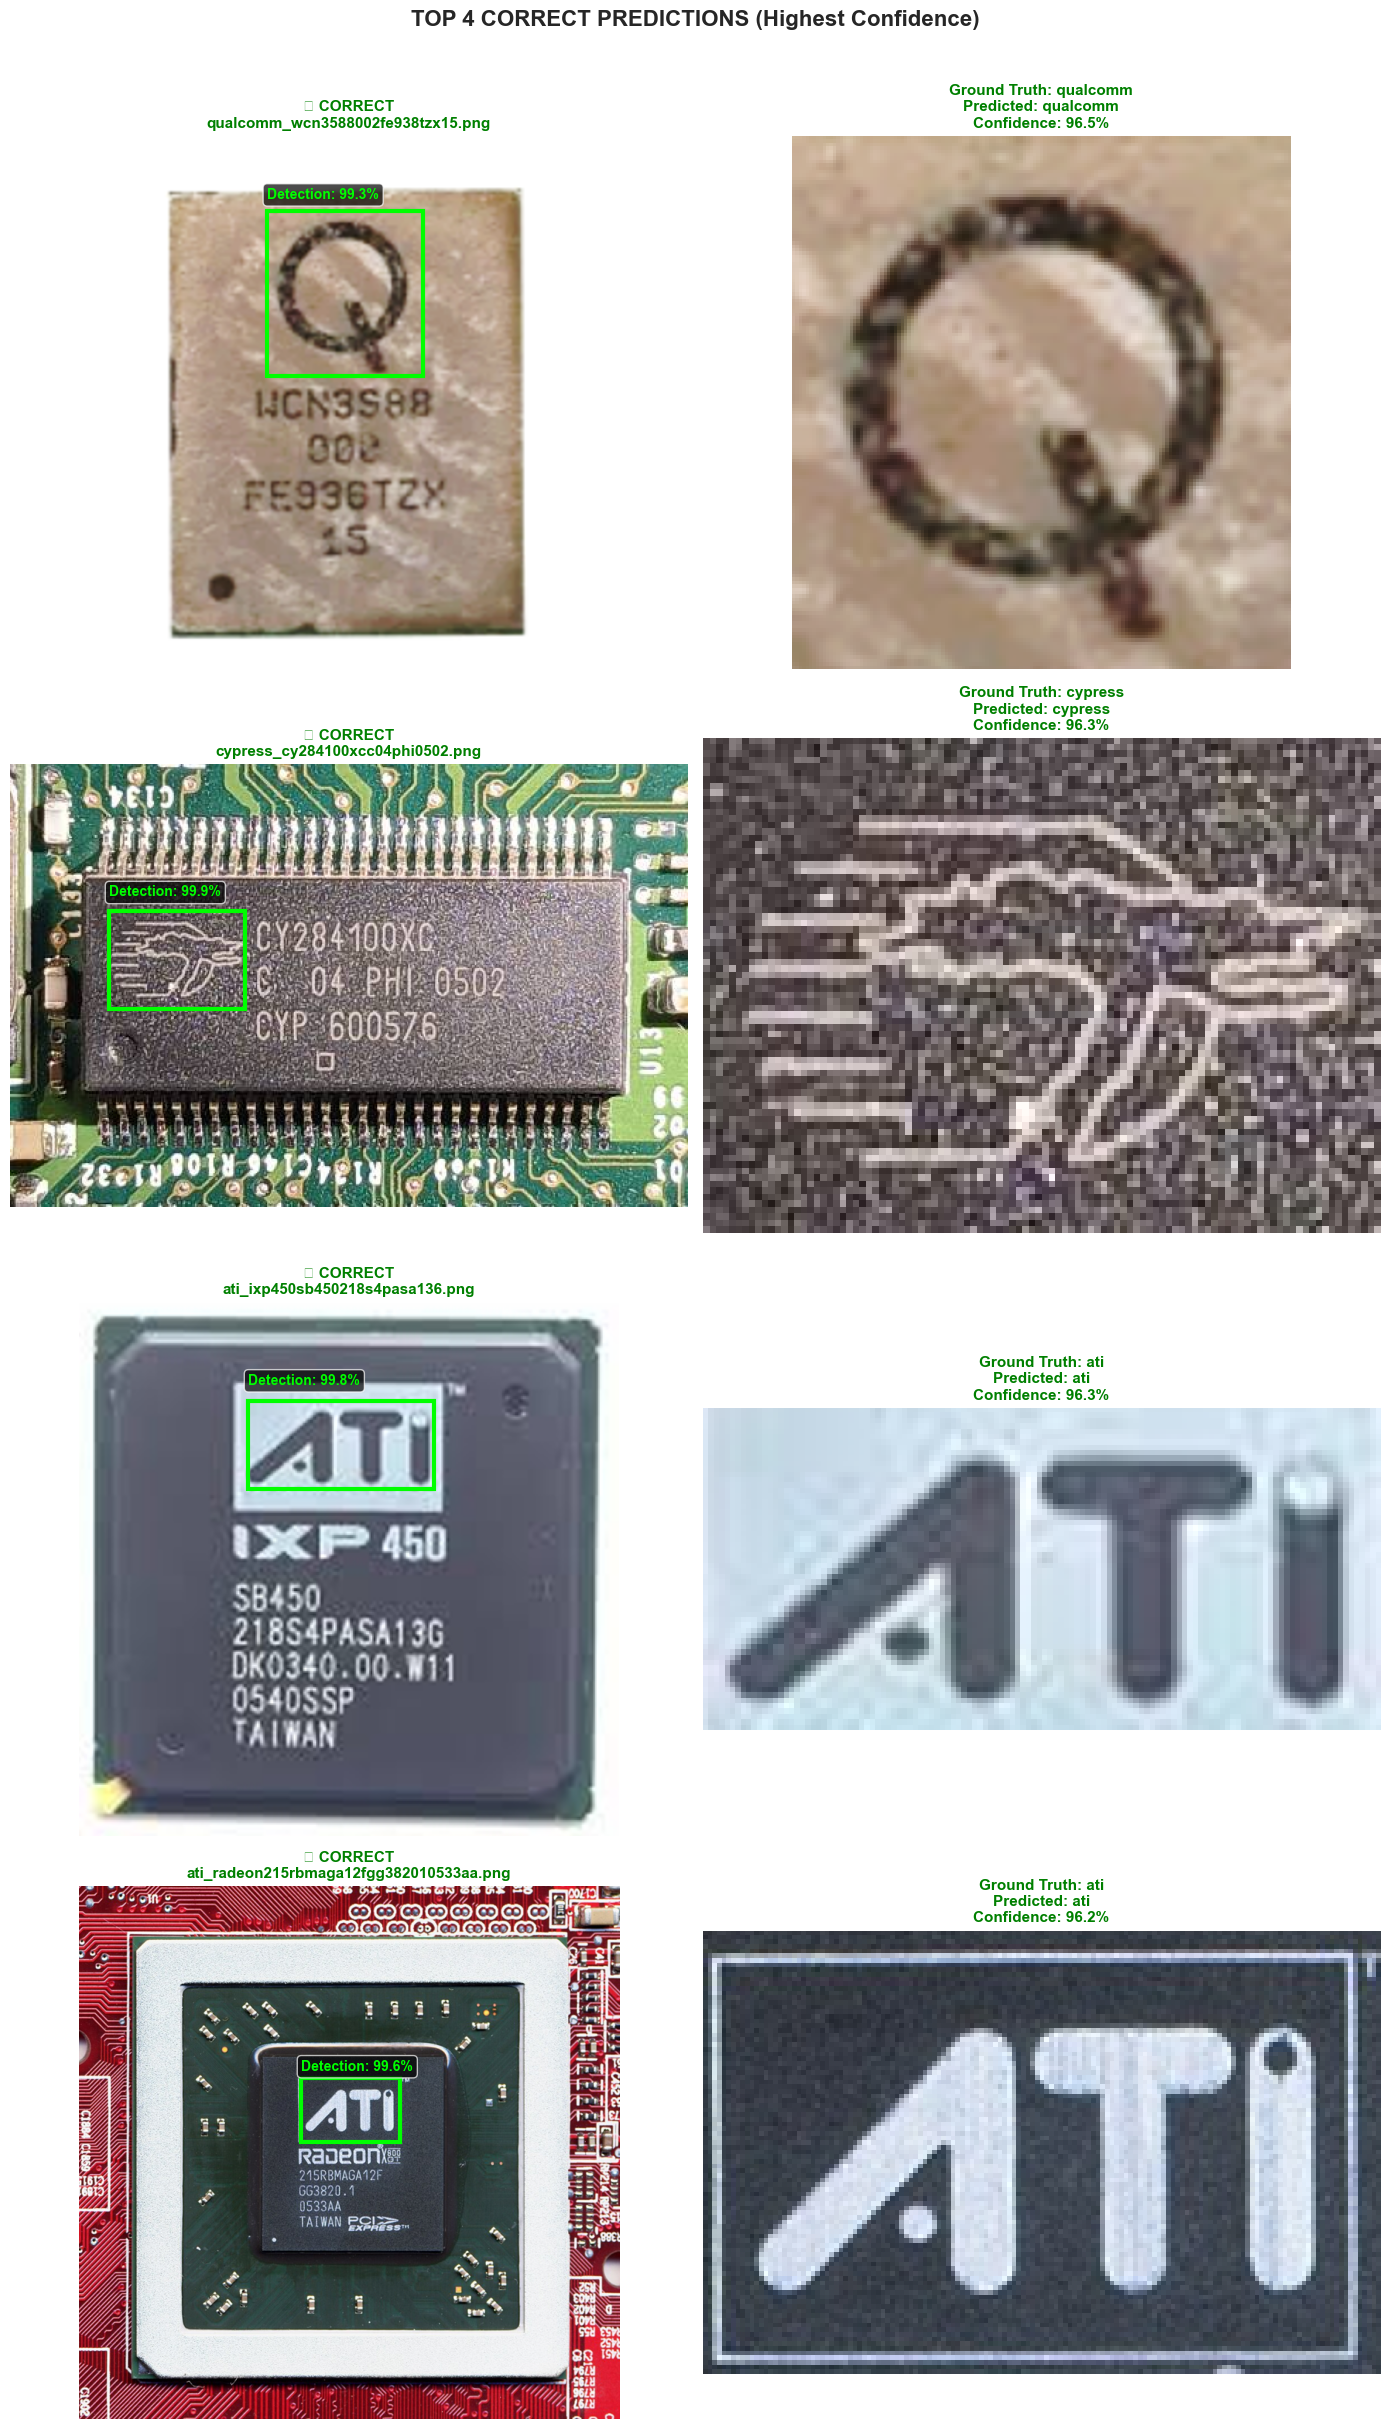

✓ Saved: top4_correct_predictions.png

TOP 4 INCORRECT PREDICTIONS (Highest Confidence Errors)



C:\Users\aaron\AppData\Local\Temp\ipykernel_31916\1521180957.py:331: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aaron\AppData\Local\Temp\ipykernel_31916\1521180957.py:332: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig('top4_incorrect_predictions.png', dpi=150, bbox_inches='tight')
C:\Users\aaron\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


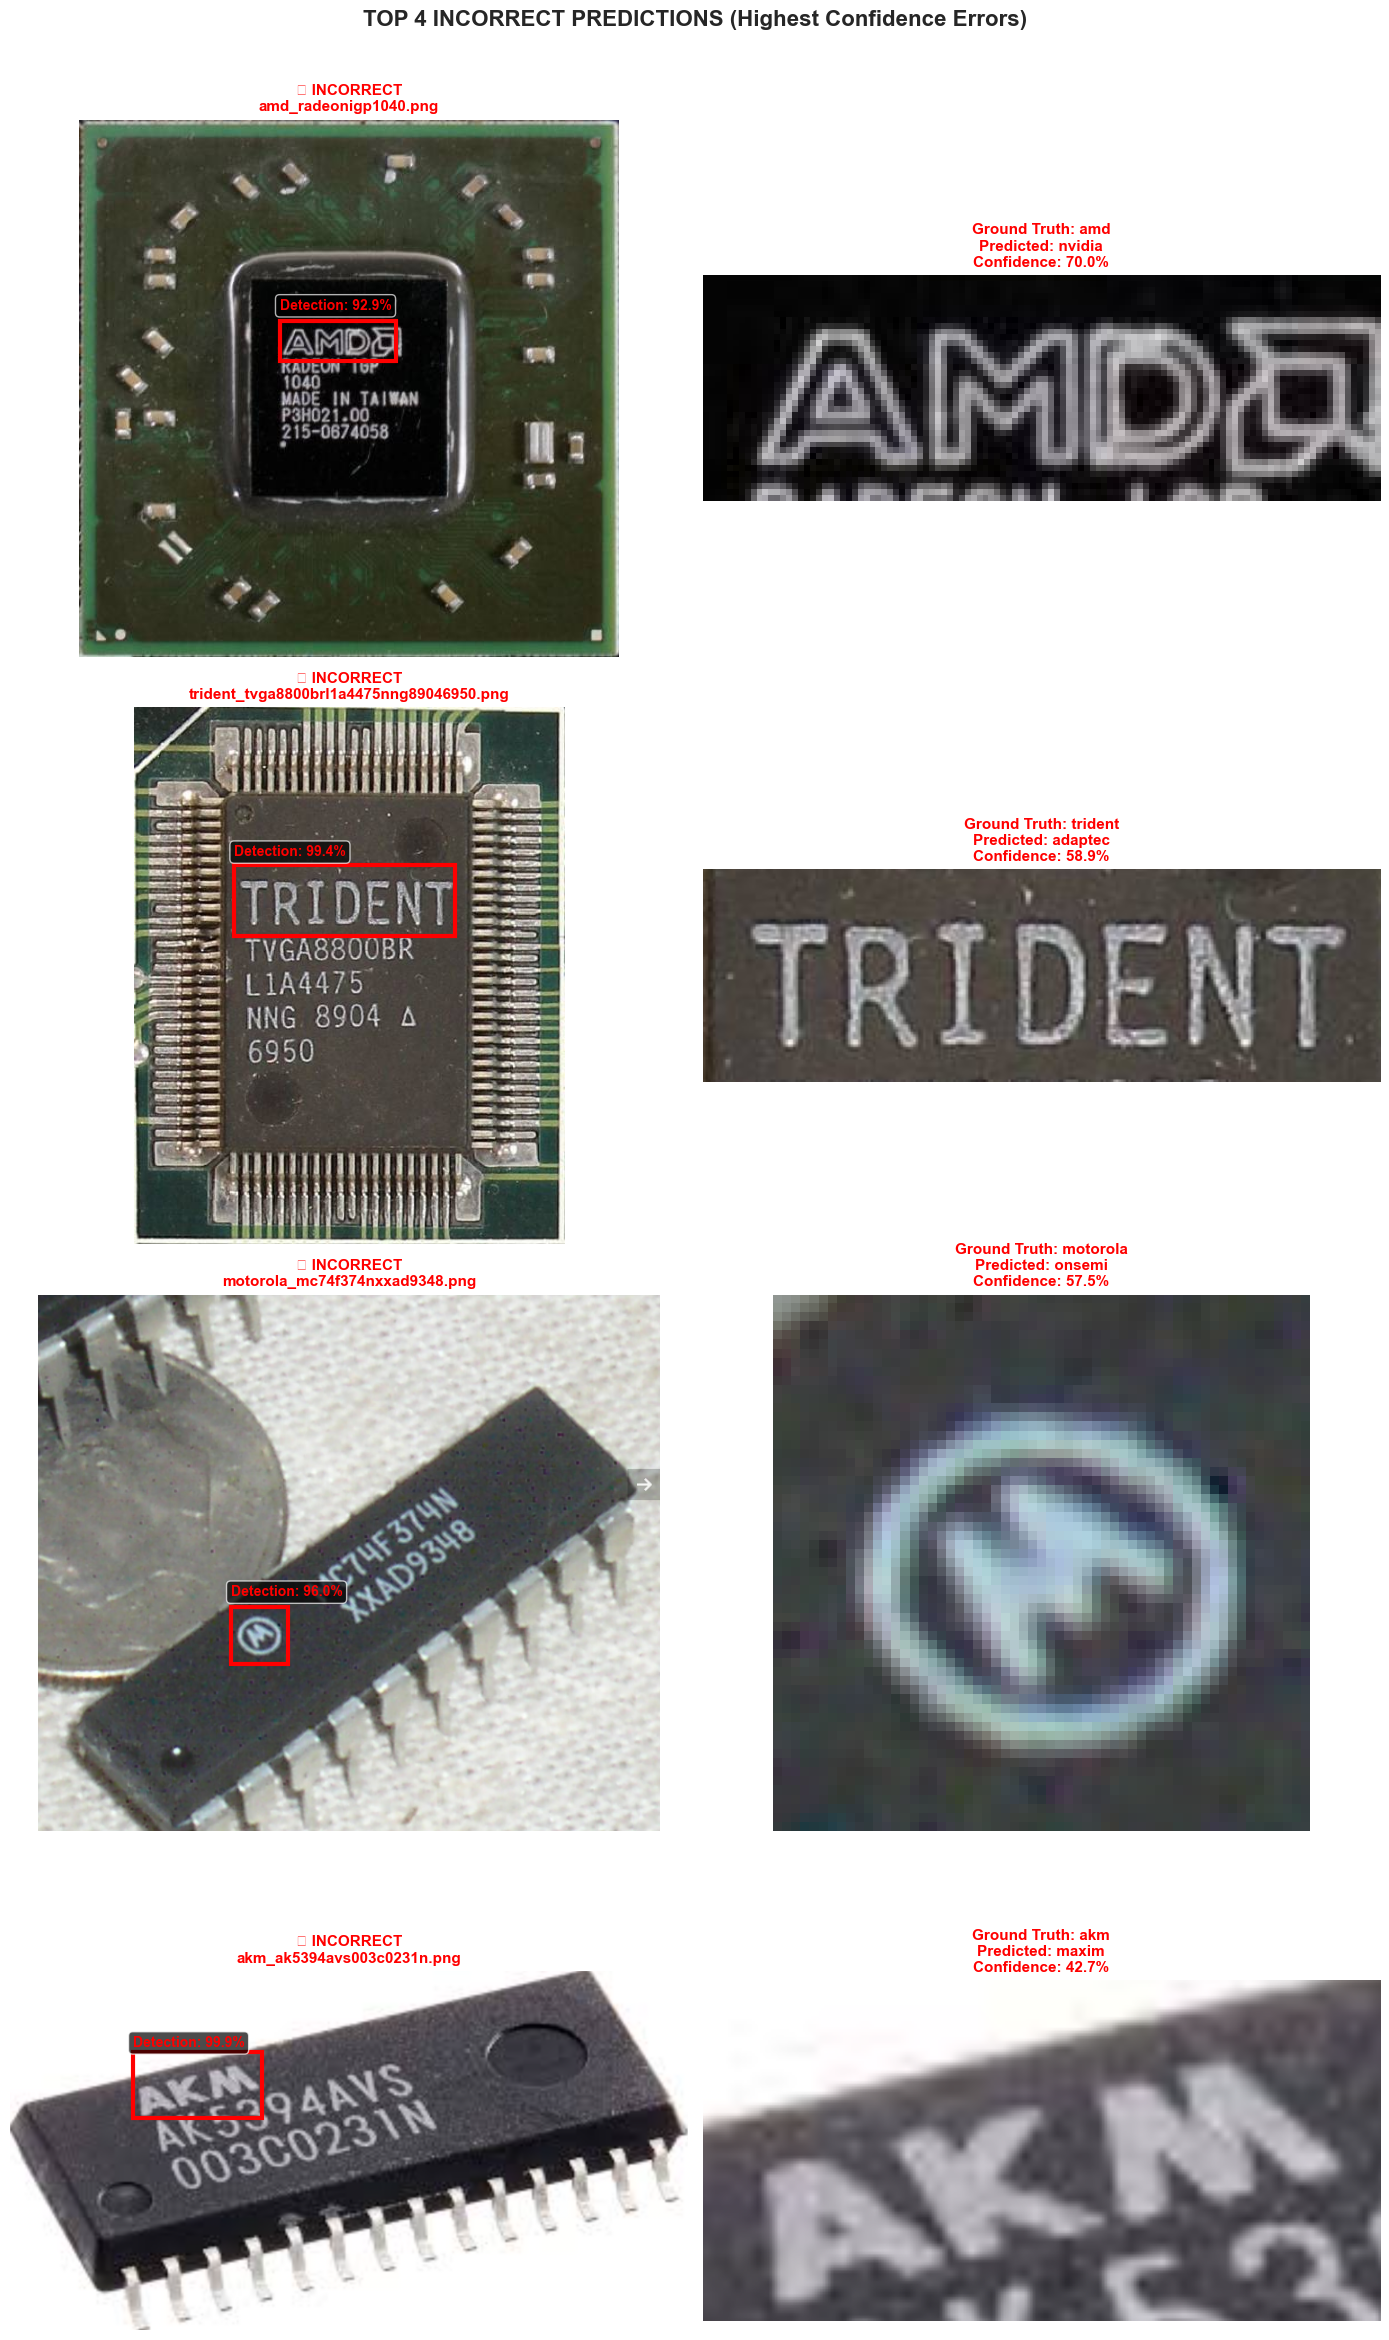

✓ Saved: top4_incorrect_predictions.png

SUMMARY
  Total test images: 474
  Correct: 470 (99.2%)
  Incorrect: 4 (0.8%)

  Top 4 correct confidence range: 96.2% - 96.5%
  Top 4 incorrect confidence range: 42.7% - 70.0%

Saved:
  - top4_correct_predictions.png
  - top4_incorrect_predictions.png



In [10]:
# ============================================================
# CELL 5: TOP CORRECT & INCORRECT PREDICTIONS VISUALIZATION
# ============================================================

import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
from sklearn.model_selection import train_test_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n", flush=True)

# ============================================================
# LOAD MODELS
# ============================================================

def load_detector(model_path='logo_detector.pth'):
    model = fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model

def load_classifier(model_path='logo_classifier_stage2.pth'):
    """Load classifier - auto-detect number of classes from saved weights"""
    
    # First, peek at the saved weights to get num_classes
    state_dict = torch.load(model_path, map_location=device)
    num_classes = state_dict['classifier.1.weight'].shape[0]
    print(f"  Detected {num_classes} classes from saved model", flush=True)
    
    model = models.efficientnet_b7(weights=None)
    num_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, num_classes)
    )
    
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model, num_classes

print("Loading models...", flush=True)
detector = load_detector('logo_detector.pth')
classifier, num_classes = load_classifier('logo_classifier_stage2.pth')
print("✓ Models loaded\n", flush=True)

# Load manufacturer names (>= 20 samples only)
manufacturers = []
for d in os.listdir('./logo_crops/'):
    mfr_dir = os.path.join('./logo_crops/', d)
    if os.path.isdir(mfr_dir):
        count = len([f for f in os.listdir(mfr_dir) if f.endswith('.png')])
        if count >= 20:
            manufacturers.append(d)

manufacturers = sorted(manufacturers)
idx_to_brand = {idx: brand for idx, brand in enumerate(manufacturers)}
brand_to_idx = {brand: idx for idx, brand in enumerate(manufacturers)}

print(f"✓ Found {len(manufacturers)} manufacturers with >= 20 samples", flush=True)
print(f"  Model classes: {num_classes}", flush=True)

# Verify alignment
if len(manufacturers) != num_classes:
    print(f"\n⚠️  WARNING: Mismatch between model ({num_classes}) and logo_crops ({len(manufacturers)})", flush=True)
    print(f"   This may happen if you added new data after training.", flush=True)
    print(f"   Using model's class count ({num_classes}) for evaluation.\n", flush=True)

print("", flush=True)

# Transforms
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ============================================================
# CREATE HELD-OUT TEST SET
# ============================================================

all_images = []
for f in os.listdir('./components/'):
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
        manufacturer = f.split('_')[0]
        if manufacturer in brand_to_idx:
            all_images.append(f)

_, test_images = train_test_split(
    all_images, 
    test_size=0.15, 
    stratify=[img.split('_')[0] for img in all_images],
    random_state=42
)

print(f"Held-out test set: {len(test_images)} images\n", flush=True)

# ============================================================
# INFERENCE WITH FULL DETAILS
# ============================================================

def predict_with_details(img_path, detector, classifier, device, 
                         idx_to_brand, val_test_transforms, detect_threshold=0.5):
    """Full two-stage pipeline returning all details for visualization"""
    
    img = Image.open(img_path).convert('RGB')
    img_tensor = transforms.ToTensor()(img).to(device)
    
    # Stage 1: Detect logo
    detector.eval()
    with torch.no_grad():
        predictions = detector([img_tensor])
    
    boxes = predictions[0]['boxes'].cpu().numpy()
    scores = predictions[0]['scores'].cpu().numpy()
    
    mask = scores >= detect_threshold
    boxes = boxes[mask]
    scores = scores[mask]
    
    if len(boxes) == 0:
        return None
    
    # Use highest confidence detection
    best_idx = scores.argmax()
    best_box = boxes[best_idx]
    detect_score = scores[best_idx]
    
    x_min, y_min, x_max, y_max = map(int, best_box)
    
    # Add padding
    pad_x = int((x_max - x_min) * 0.05)
    pad_y = int((y_max - y_min) * 0.05)
    x_min_pad = max(0, x_min - pad_x)
    y_min_pad = max(0, y_min - pad_y)
    x_max_pad = min(img.width, x_max + pad_x)
    y_max_pad = min(img.height, y_max + pad_y)
    
    # Crop logo
    logo_crop = img.crop((x_min_pad, y_min_pad, x_max_pad, y_max_pad))
    
    # Stage 2: Classify
    logo_tensor = val_test_transforms(logo_crop).unsqueeze(0).to(device)
    
    classifier.eval()
    with torch.no_grad():
        output = classifier(logo_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, pred_idx = torch.max(probs, 1)
    
    pred_idx_val = pred_idx.item()
    
    # Handle case where prediction index exceeds our manufacturer list
    if pred_idx_val < len(idx_to_brand):
        brand = idx_to_brand[pred_idx_val]
    else:
        brand = f"unknown_class_{pred_idx_val}"
    
    return {
        'image': img,
        'box': best_box,
        'detect_score': detect_score,
        'logo_crop': logo_crop,
        'pred_brand': brand,
        'pred_confidence': confidence.item()
    }

# ============================================================
# RUN PREDICTIONS ON TEST SET
# ============================================================

print("="*60, flush=True)
print("RUNNING PREDICTIONS ON HELD-OUT TEST SET", flush=True)
print("="*60 + "\n", flush=True)

results = []

for idx, img_file in enumerate(test_images):
    gt_manufacturer = img_file.split('_')[0]
    img_path = os.path.join('./components/', img_file)
    
    prediction = predict_with_details(
        img_path, detector, classifier, device, idx_to_brand, val_test_transforms
    )
    
    if prediction is None:
        continue
    
    results.append({
        'image_file': img_file,
        'image': prediction['image'],
        'box': prediction['box'],
        'detect_score': prediction['detect_score'],
        'logo_crop': prediction['logo_crop'],
        'gt': gt_manufacturer,
        'pred': prediction['pred_brand'],
        'confidence': prediction['pred_confidence'],
        'correct': gt_manufacturer == prediction['pred_brand']
    })
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx+1}/{len(test_images)} images...", flush=True)

print(f"\n✓ Processed {len(results)} images\n", flush=True)

# ============================================================
# SEPARATE CORRECT AND INCORRECT
# ============================================================

correct_results = [r for r in results if r['correct']]
wrong_results = [r for r in results if not r['correct']]

# Sort by confidence (highest first)
correct_sorted = sorted(correct_results, key=lambda x: x['confidence'], reverse=True)
wrong_sorted = sorted(wrong_results, key=lambda x: x['confidence'], reverse=True)

print(f"Correct predictions: {len(correct_results)}", flush=True)
print(f"Incorrect predictions: {len(wrong_results)}", flush=True)
print(f"Accuracy: {100*len(correct_results)/len(results):.2f}%\n", flush=True)

# ============================================================
# VISUALIZE TOP 4 CORRECT PREDICTIONS
# ============================================================

print("="*60, flush=True)
print("TOP 4 CORRECT PREDICTIONS (Highest Confidence)", flush=True)
print("="*60 + "\n", flush=True)

fig, axes = plt.subplots(4, 2, figsize=(14, 24))

for i, result in enumerate(correct_sorted[:4]):
    # Left: Original image with bounding box
    ax_img = axes[i, 0]
    ax_img.imshow(result['image'])
    
    # Draw bounding box
    x_min, y_min, x_max, y_max = result['box']
    rect = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=3, edgecolor='lime', facecolor='none'
    )
    ax_img.add_patch(rect)
    
    # Add detection confidence label
    ax_img.text(x_min, max(y_min - 10, 10), 
                f"Detection: {result['detect_score']*100:.1f}%",
                color='lime', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    ax_img.set_title(f"✓ CORRECT\n{result['image_file'][:40]}", 
                     fontsize=11, fontweight='bold', color='green')
    ax_img.axis('off')
    
    # Right: Cropped logo with stats
    ax_logo = axes[i, 1]
    ax_logo.imshow(result['logo_crop'])
    ax_logo.set_title(
        f"Ground Truth: {result['gt']}\n"
        f"Predicted: {result['pred']}\n"
        f"Confidence: {result['confidence']*100:.1f}%",
        fontsize=11, fontweight='bold', color='green'
    )
    ax_logo.axis('off')

plt.suptitle('TOP 4 CORRECT PREDICTIONS (Highest Confidence)', 
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('top4_correct_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: top4_correct_predictions.png\n", flush=True)

# ============================================================
# VISUALIZE TOP 4 INCORRECT PREDICTIONS
# ============================================================

print("="*60, flush=True)
print("TOP 4 INCORRECT PREDICTIONS (Highest Confidence Errors)", flush=True)
print("="*60 + "\n", flush=True)

if len(wrong_sorted) >= 4:
    fig, axes = plt.subplots(4, 2, figsize=(14, 24))
    
    for i, result in enumerate(wrong_sorted[:4]):
        # Left: Original image with bounding box
        ax_img = axes[i, 0]
        ax_img.imshow(result['image'])
        
        # Draw bounding box
        x_min, y_min, x_max, y_max = result['box']
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=3, edgecolor='red', facecolor='none'
        )
        ax_img.add_patch(rect)
        
        # Add detection confidence label
        ax_img.text(x_min, max(y_min - 10, 10), 
                    f"Detection: {result['detect_score']*100:.1f}%",
                    color='red', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        ax_img.set_title(f"✗ INCORRECT\n{result['image_file'][:40]}", 
                         fontsize=11, fontweight='bold', color='red')
        ax_img.axis('off')
        
        # Right: Cropped logo with stats
        ax_logo = axes[i, 1]
        ax_logo.imshow(result['logo_crop'])
        ax_logo.set_title(
            f"Ground Truth: {result['gt']}\n"
            f"Predicted: {result['pred']}\n"
            f"Confidence: {result['confidence']*100:.1f}%",
            fontsize=11, fontweight='bold', color='red'
        )
        ax_logo.axis('off')
    
    plt.suptitle('TOP 4 INCORRECT PREDICTIONS (Highest Confidence Errors)', 
                 fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('top4_incorrect_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: top4_incorrect_predictions.png\n", flush=True)

elif len(wrong_sorted) > 0:
    print(f"⚠️  Only {len(wrong_sorted)} incorrect predictions - showing all:\n", flush=True)
    
    num_wrong = len(wrong_sorted)
    fig, axes = plt.subplots(num_wrong, 2, figsize=(14, 6*num_wrong))
    if num_wrong == 1:
        axes = axes.reshape(1, -1)
    
    for i, result in enumerate(wrong_sorted):
        ax_img = axes[i, 0]
        ax_img.imshow(result['image'])
        
        x_min, y_min, x_max, y_max = result['box']
        rect = patches.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            linewidth=3, edgecolor='red', facecolor='none'
        )
        ax_img.add_patch(rect)
        
        ax_img.text(x_min, max(y_min - 10, 10), 
                    f"Detection: {result['detect_score']*100:.1f}%",
                    color='red', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        ax_img.set_title(f"✗ INCORRECT\n{result['image_file'][:40]}", 
                         fontsize=11, fontweight='bold', color='red')
        ax_img.axis('off')
        
        ax_logo = axes[i, 1]
        ax_logo.imshow(result['logo_crop'])
        ax_logo.set_title(
            f"Ground Truth: {result['gt']}\n"
            f"Predicted: {result['pred']}\n"
            f"Confidence: {result['confidence']*100:.1f}%",
            fontsize=11, fontweight='bold', color='red'
        )
        ax_logo.axis('off')
    
    plt.suptitle('ALL INCORRECT PREDICTIONS', fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('top4_incorrect_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Saved: top4_incorrect_predictions.png\n", flush=True)

else:
    print("🎉 No incorrect predictions! Perfect accuracy on held-out test set.\n", flush=True)

# ============================================================
# SUMMARY
# ============================================================

print("="*60, flush=True)
print("SUMMARY", flush=True)
print("="*60, flush=True)
print(f"  Total test images: {len(results)}", flush=True)
print(f"  Correct: {len(correct_results)} ({100*len(correct_results)/len(results):.1f}%)", flush=True)
print(f"  Incorrect: {len(wrong_results)} ({100*len(wrong_results)/len(results):.1f}%)", flush=True)
print(f"", flush=True)

if len(correct_sorted) >= 4:
    print(f"  Top 4 correct confidence range: "
          f"{correct_sorted[3]['confidence']*100:.1f}% - {correct_sorted[0]['confidence']*100:.1f}%", flush=True)

if len(wrong_sorted) >= 4:
    print(f"  Top 4 incorrect confidence range: "
          f"{wrong_sorted[3]['confidence']*100:.1f}% - {wrong_sorted[0]['confidence']*100:.1f}%", flush=True)
elif len(wrong_sorted) > 0:
    print(f"  Incorrect confidence range: "
          f"{wrong_sorted[-1]['confidence']*100:.1f}% - {wrong_sorted[0]['confidence']*100:.1f}%", flush=True)

print(f"", flush=True)
print(f"Saved:", flush=True)
print(f"  - top4_correct_predictions.png", flush=True)
print(f"  - top4_incorrect_predictions.png", flush=True)
print(f"{'='*60}\n", flush=True)